# Analiza histogramowa i boxplotowa pierwszego utworzonego zbioru
W tym notatniku wczytujemy pierwszy utworzony zbiór po imputacji i skalowaniu, a następnie wykonujemy analizę rozkładów cech numerycznych za pomocą histogramów i wykresów pudełkowych.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

In [3]:
data_dir = Path("./data")

# Wpisz nazwe konkretnego pliku dla tego notatnika
dataset_filename = "loan_data_automl_minmax.csv"

selected_dataset_path = data_dir / dataset_filename
if not selected_dataset_path.exists():
    available_files = sorted([p.name for p in data_dir.glob("loan_data_*_*.csv")])
    raise FileNotFoundError(
        f"Nie znaleziono pliku: {selected_dataset_path}\nDostepne pliki: {available_files}"
    )

print(f"Wczytywany zbior: {selected_dataset_path}")
df = pd.read_csv(selected_dataset_path)
display(df.head())

Wczytywany zbior: data/loan_data_automl_minmax.csv


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,0.016129,male,Master,0.009212,0.002428,RENT,1.000000,PERSONAL,0.537661,0.742424,0.035714,0.570023,No,1
1,0.008065,female,High School,0.000920,0.000000,OWN,0.016149,EDUCATION,0.392318,0.121212,0.000000,0.464254,Yes,0
2,0.040323,female,High School,0.000941,0.024000,MORTGAGE,0.144928,HOMEIMPROVEMENT,0.510974,0.666667,0.035714,0.556701,No,1
3,0.024194,female,Bachelor,0.010297,0.000000,RENT,1.000000,MEDICAL,0.672840,0.666667,0.000000,0.659794,No,1
4,0.032258,male,Master,0.008404,0.008000,RENT,1.000000,MEDICAL,0.577242,0.803030,0.071429,0.430412,No,1


In [4]:
print("Ksztalt danych:", df.shape)
print("\nTypy kolumn:")
display(df.dtypes.to_frame("dtype"))

print("\nBraki danych:")
display(df.isna().sum().to_frame("missing_count"))

num_cols = [
    col for col in df.select_dtypes(include=[np.number]).columns.tolist()
    if col != "loan_status"
]
print(f"\nLiczba kolumn numerycznych (bez loan_status): {len(num_cols)}")
print("Kolumny numeryczne:", num_cols)

Ksztalt danych: (45000, 14)

Typy kolumn:


,dtype
person_age,float64
person_gender,object
person_education,object
person_income,float64
person_emp_exp,float64
person_home_ownership,object
loan_amnt,float64
loan_intent,object
loan_int_rate,float64
loan_percent_income,float64



Braki danych:


,missing_count
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0



Liczba kolumn numerycznych (bez loan_status): 8
Kolumny numeryczne: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


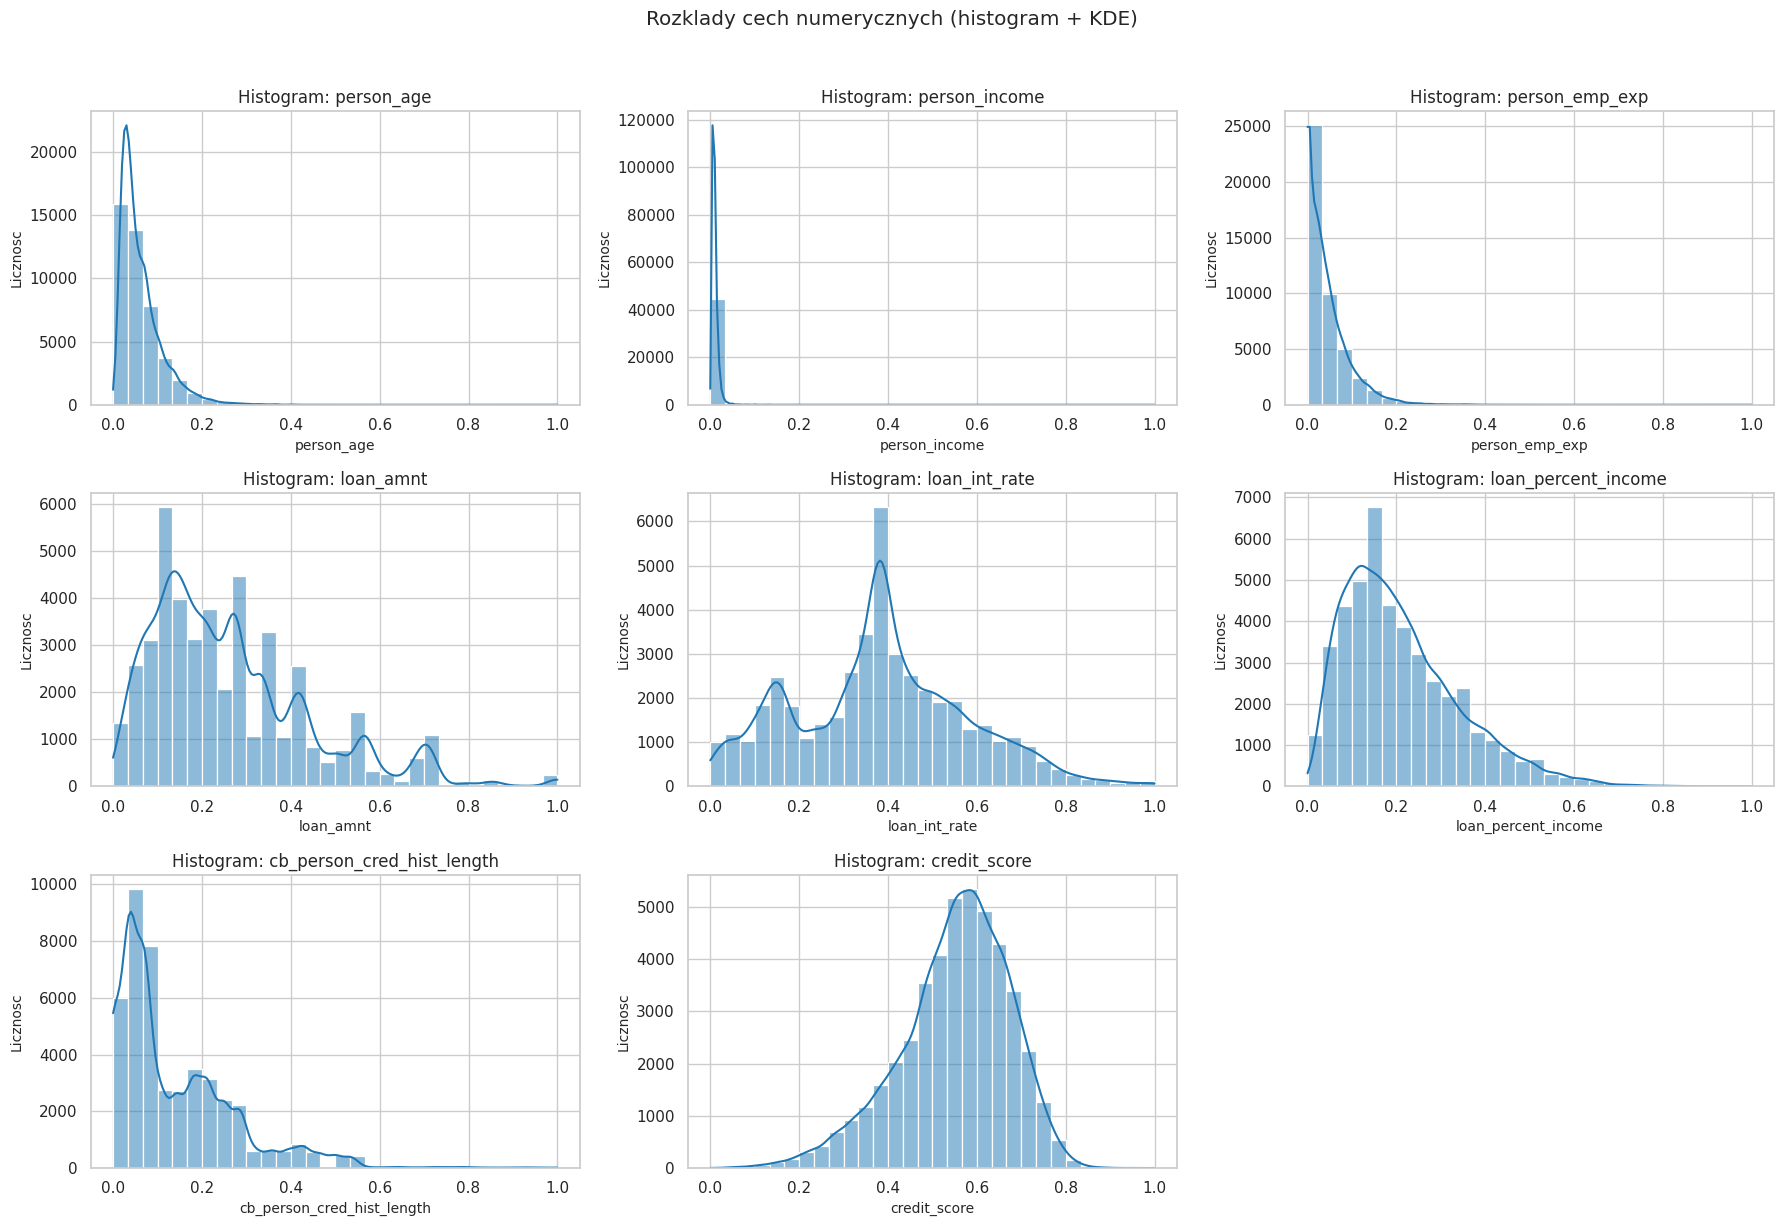

In [5]:
# Analiza histogramowa wszystkich kolumn numerycznych
n_cols = 3
n_rows = int(np.ceil(len(num_cols) / n_cols)) if num_cols else 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(num_cols):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i], color="#1f77b4")
    axes[i].set_title(f"Histogram: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Licznosc")

for j in range(len(num_cols), len(axes)):
    axes[j].axis("off")

plt.suptitle("Rozklady cech numerycznych (histogram + KDE)", y=1.02)
plt.tight_layout()
plt.show()

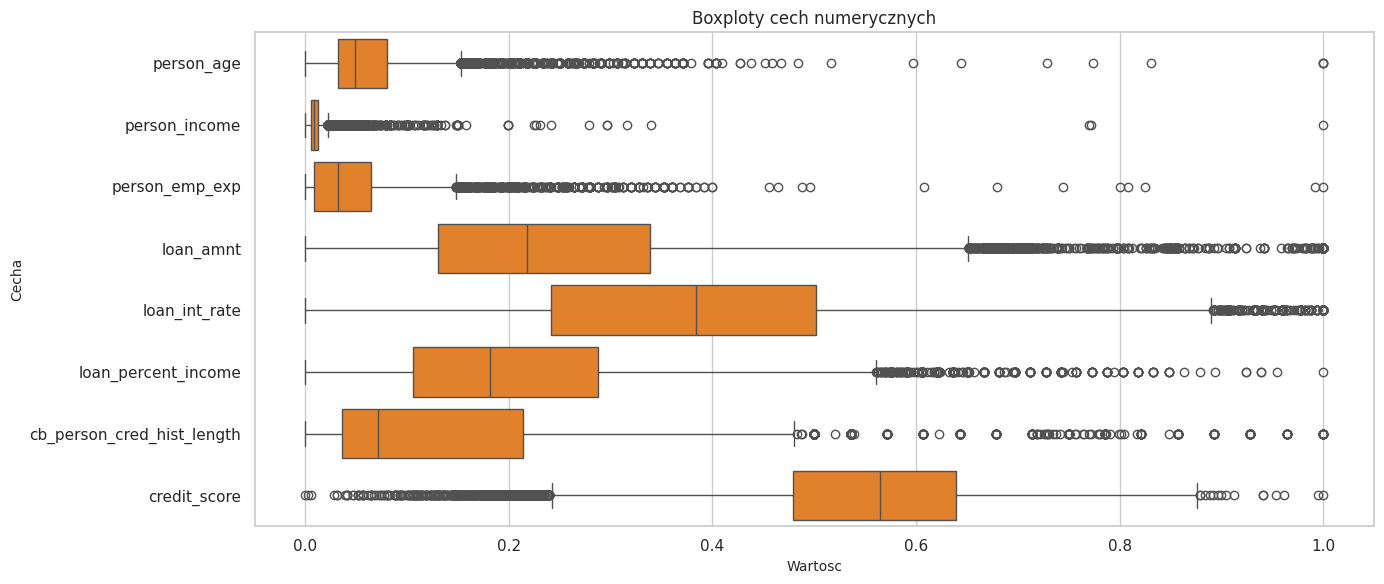

In [6]:
# Analiza boxplotowa wszystkich kolumn numerycznych
if num_cols:
    plot_df = df[num_cols].melt(var_name="cecha", value_name="wartosc")
    
    plt.figure(figsize=(14, max(6, 0.5 * len(num_cols))))
    sns.boxplot(data=plot_df, y="cecha", x="wartosc", orient="h", color="#ff7f0e")
    plt.title("Boxploty cech numerycznych")
    plt.xlabel("Wartosc")
    plt.ylabel("Cecha")
    plt.tight_layout()
    plt.show()
else:
    print("Brak kolumn numerycznych do analizy boxplotowej.")

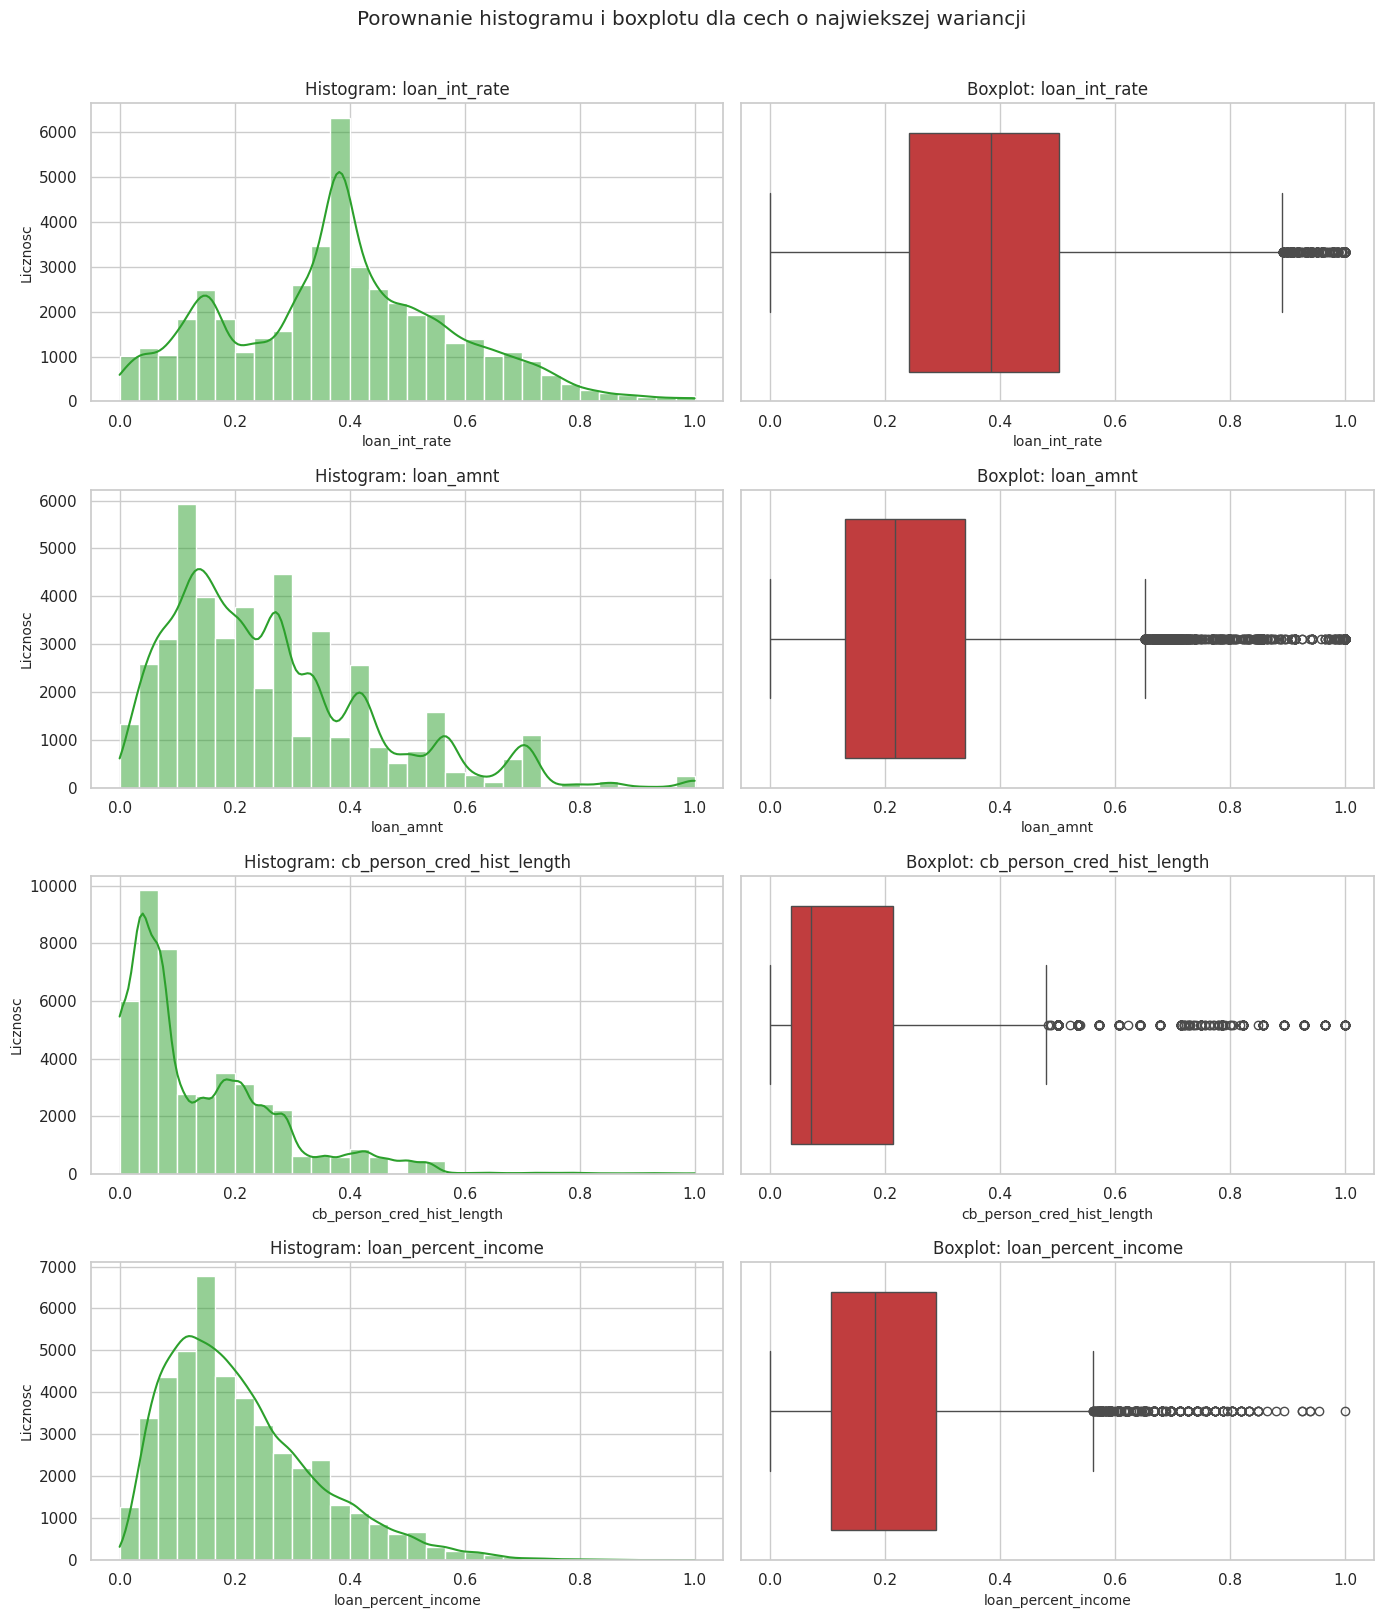

In [7]:
# Porownanie histogramow i boxplotow dla wybranych cech
top_features = df[num_cols].var(numeric_only=True).sort_values(ascending=False).head(4).index.tolist() if num_cols else []

if top_features:
    fig, axes = plt.subplots(len(top_features), 2, figsize=(14, 4 * len(top_features)))
    if len(top_features) == 1:
        axes = np.array([axes])

    for i, feature in enumerate(top_features):
        sns.histplot(df[feature], bins=30, kde=True, ax=axes[i, 0], color="#2ca02c")
        axes[i, 0].set_title(f"Histogram: {feature}")
        axes[i, 0].set_xlabel(feature)
        axes[i, 0].set_ylabel("Licznosc")

        sns.boxplot(x=df[feature], ax=axes[i, 1], color="#d62728")
        axes[i, 1].set_title(f"Boxplot: {feature}")
        axes[i, 1].set_xlabel(feature)

    plt.suptitle("Porownanie histogramu i boxplotu dla cech o najwiekszej wariancji", y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("Brak kolumn numerycznych do porownania histogramow i boxplotow.")

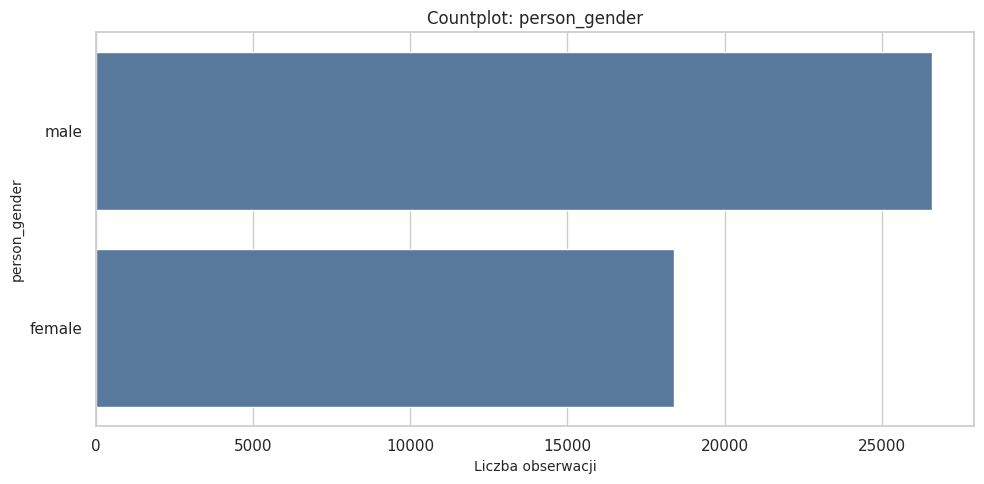

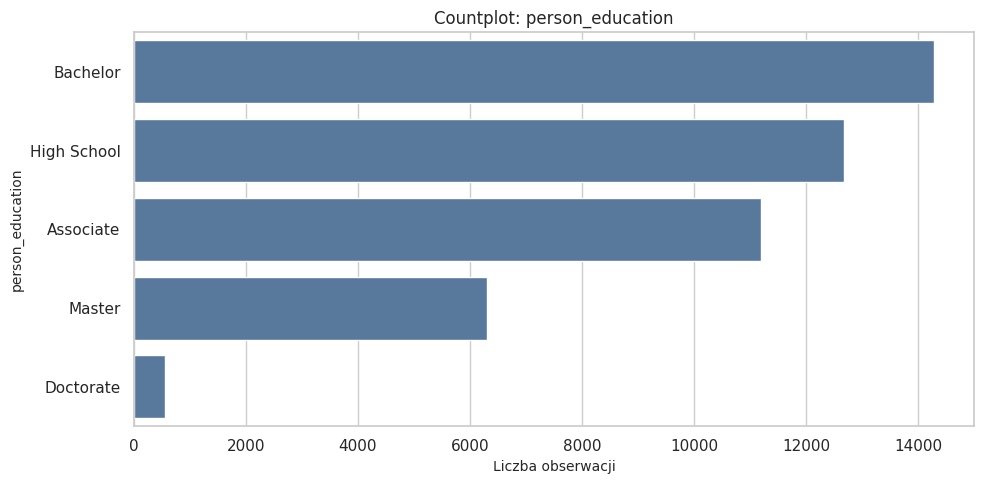

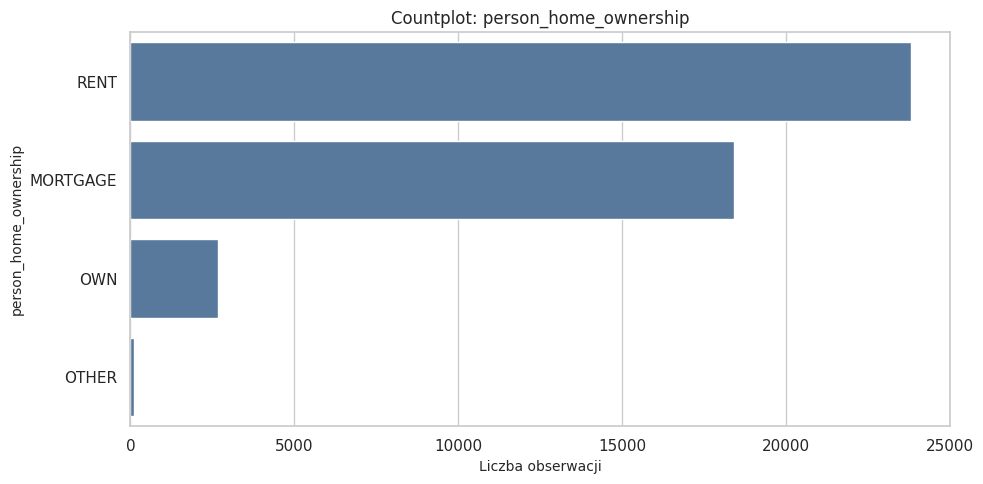

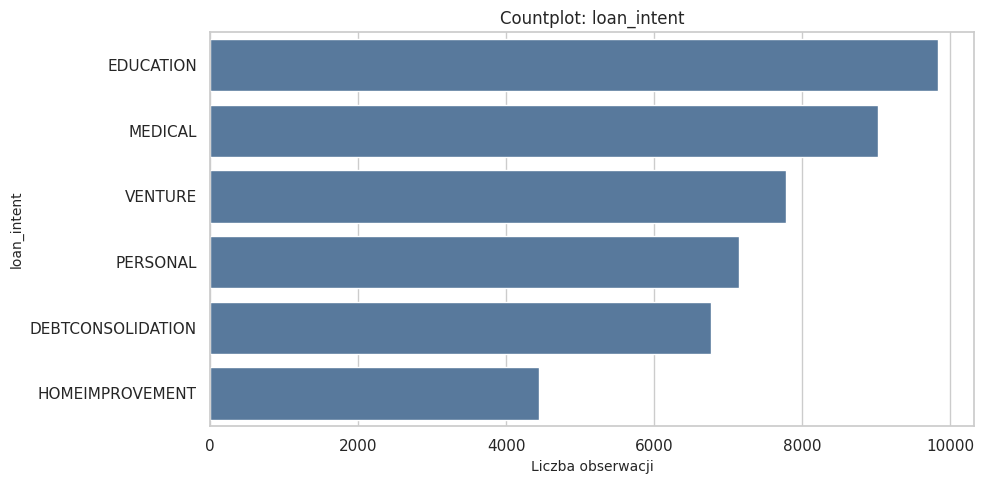

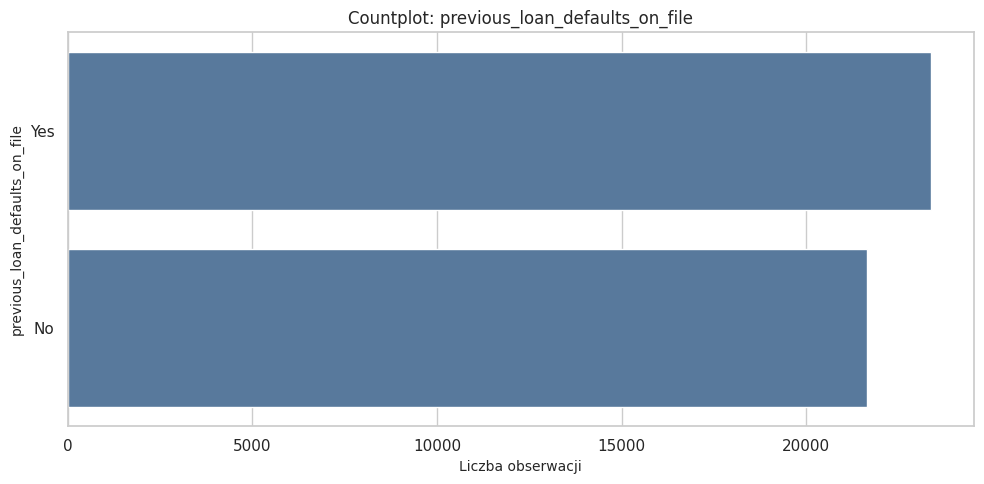

In [8]:
# Countplot dla kolumn nienumerycznych (bez loan_status)
cat_cols = [
    col for col in df.select_dtypes(exclude=[np.number]).columns.tolist()
    if col != "loan_status"
]

if not cat_cols:
    print("Brak kolumn nienumerycznych do wizualizacji countplot.")
else:
    for col in cat_cols:
        plt.figure(figsize=(10, 5))
        order = df[col].astype(str).value_counts().index
        sns.countplot(
            y=df[col].astype(str),
            order=order,
            color="#4c78a8"
        )
        plt.title(f"Countplot: {col}")
        plt.xlabel("Liczba obserwacji")
        plt.ylabel(col)
        plt.tight_layout()
        plt.show()